# Agentic Design Patterns: Plan & Execute

Welcome to the second pattern: **Plan-and-Execute**.

Large language models often struggle when told to perform complex, multi-step actions in one go. If you say "*Research Apple's Q3 earnings, compare them to Microsoft's, and write a summary report highlighting the key differences in services revenue,*" a single ReAct (Reason+Act) agent will often get confused halfway through.

The **Plan-and-Execute** architecture separates *planning* from *execution*. 
1. **Planner Agent**: Generates a step-by-step checklist of what needs to be done.
2. **Executor Agent(s)**: Takes the first step, completes it, and updates the shared memory.
3. **Replanner Agent**: Looks at the completed step and the remaining plan, deciding if the plan needs modification before continuing.

---

## 1. Environment Setup

In [1]:
import os
from typing import Annotated, TypedDict, List
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

load_dotenv()
# We will use the same LLM for all roles here, but as a Pro-tip:
# Planners benefit from highly capable reasoning models (like Gemini Pro).
# Executors can often be faster/cheaper models (like Gemini Flash).
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

print("Plan & Execute Environment Ready!")

/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:234: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with cri

Plan & Execute Environment Ready!


## 2. Shared State and Pydantic Schemas
The most critical part of this pattern is ensuring the Planner outputs a structured list of steps, and maintaining a `plan` array in our state.

In [2]:
# The structure the Planner MUST return
class Plan(BaseModel):
    """A step-by-step plan to achieve a goal."""
    steps: List[str] = Field(description="List of specific, actionable steps to complete the task.")

class PlanExecuteState(TypedDict):
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]
    plan: List[str]          # The remaining steps
    past_steps: List[str]    # What we've already done
    response: str            # The final output to the user

planner_llm = llm.with_structured_output(Plan)

## 3. Defining the Agent Nodes

In [3]:
def planner_node(state: PlanExecuteState):
    print("--- PLANNER IS THINKING ---")
    system_msg = SystemMessage(
        content="For the given objective, generate a simple step-by-step plan. "
                "Keep steps granular and actionable."
    )
    # Generate the initial plan
    response = planner_llm.invoke([system_msg] + state["messages"])
    # Return a dictionary that overwrites the 'plan' array in the State
    return {"plan": response.steps, "past_steps": []}

def executor_node(state: PlanExecuteState):
    # Take the VERY FIRST step off the top of the plan
    current_step = state["plan"][0]
    print(f"\n--- EXECUTOR IS RUNNING STEP: {current_step} ---")
    
    # In a real system, you would pass `current_step` into an Agentic Tool Graph!
    # Here, we simulate the execution by just asking the LLM to complete it:
    executor_prompt = f"""You are the executor. Your task is to complete precisely this step:
    <step>
    {current_step}
    </step>
    Provide the result of this step.
    """
    
    response = llm.invoke([HumanMessage(content=executor_prompt)])
    
    # We format the past step as a string showing what was done.
    completed_step_str = f"Step: {current_step}\nResult: {response.content}"
    
    # Return the updated state:
    return {
        "past_steps": state.get("past_steps", []) + [completed_step_str],
    }

# Replanning is where the magic happens.
class ReplannerUpdate(BaseModel):
    """Either give a new plan, or finish the task."""
    new_plan_steps: List[str] = Field(description="The remaining steps needed, updated based on recent findings.")
    is_finished: bool = Field(description="If no more steps are needed, set to True.")
    final_response: str = Field(description="If finished, the final text to return to the user.")

replanner_llm = llm.with_structured_output(ReplannerUpdate)

def replanner_node(state: PlanExecuteState):
    print("--- REPLANNER IS EVALUATING PROGRESS ---")
    replanner_prompt = f"""You are evaluating task completion.
    Original Goal: {state['messages'][0].content}
    
    What we have done so far:
    {state['past_steps'][-1] if state.get('past_steps') else 'Nothing yet.'}
    
    Remaining plan:
    {state['plan'][1:]}
    
    Assess progress. Focus strictly on whether the original goal is complete.
    Provide updated remaining steps, or set is_finished to True.
    """
    
    response = replanner_llm.invoke([HumanMessage(content=replanner_prompt)])
    
    if response.is_finished:
        # Goal met!
        return {"plan": [], "response": response.final_response}
    else:
        # Replace the remaining plan with the Replanner's updated steps
        return {"plan": response.new_plan_steps}


def should_continue(state: PlanExecuteState):
    # After replanning, do we have any steps left?
    if not state["plan"]:
        return END
    return "executor"


## 4. Compile and Visualize

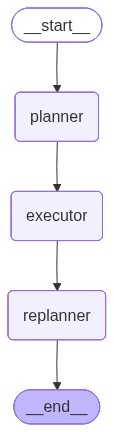

In [4]:
builder = StateGraph(PlanExecuteState)

builder.add_node("planner", planner_node)
builder.add_node("executor", executor_node)
builder.add_node("replanner", replanner_node)

builder.add_edge(START, "planner")
# Step 1: Planner creates the checklist, hands it to Executor
builder.add_edge("planner", "executor")
# Step 2: Executor finishes ONE step, hands it to Replanner
builder.add_edge("executor", "replanner")
# Step 3: Replanner decides if we are done or go back to Executor
builder.add_conditional_edges("replanner", should_continue)

app = builder.compile()

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed.")

## 5. Running the Pattern
Let's assign a multi-step writing task.

In [ ]:
query = "Write a short sci-fi story. First, write an outline. Then, write the setting description. Finally, combine it into the full story."

initial_state = {
    "messages": [HumanMessage(content=query)],
}

# Warning: We will break out of the loop if it gets stuck to avoid infinite token spend
step_count = 0
for chunk in app.stream(initial_state):
    if "planner" in chunk:
        print(f"\nFINAL INITIAL PLAN:")
        for step in chunk["planner"]["plan"]:
            print(f" - {step}")
            
    elif "executor" in chunk:
        # Print just the result of the executed step
        print(f"-> Execution Result Logged.")
        
    elif "replanner" in chunk:
        if chunk["replanner"].get("response"):
            print(f"\n*** FINAL RESPONSE ISSUED ***\n{chunk['replanner']['response']}")
        else:
            print(f"-> Plan Updated. Remaining steps: {len(chunk['replanner']['plan'])}")
            
    step_count += 1
    if step_count > 15:
        print("Forcing exit - loop limit reached.")
        break

--- PLANNER IS THINKING ---

FINAL INITIAL PLAN:
 - Introduce Captain Eva Rostova, a solitary xeno-archaeologist, on the desolate planet Xylos-7.
 - Describe her discovery of a massive, ancient alien structure partially buried in the red dust.
 - Eva enters the structure, navigating through dimly lit corridors filled with strange glyphs.
 - She finds a central chamber with a pulsating artifact.
 - Eva activates the artifact, which projects a holographic warning of an impending cosmic threat.
 - The structure begins to destabilize, and Eva realizes she's awakened something dangerous.
 - Eva races back to her ship, narrowly escaping as the structure collapses or transforms.
 - She transmits the warning, now burdened with the knowledge of the coming danger.

--- EXECUTOR IS RUNNING STEP: Introduce Captain Eva Rostova, a solitary xeno-archaeologist, on the desolate planet Xylos-7. ---
-> Execution Result Logged.
--- REPLANNER IS EVALUATING PROGRESS ---
-> Plan Updated. Remaining steps: 7



## Summary

The **Plan & Execute** pattern solves the "context limit / confusion" problem.

By forcing the LLM to write down what it is going to do *before* it tries to do it, you massively increase the reliability of complex workflows. The Replanner specifically allows the workflow to adapt if step 1 doesn't go exactly as expected. 

> **Caution**: Planners can sometimes create highly detailed, 20-step plans which take ages (and significant LLM API cost) to execute layer by layer. Always enforce a max step count in the Planner prompt for cost control.